# Neural Symbolic Regression that Scales

**Paper:** Biggio, L., Bendinelli, T., Neitz, A., Lucchi, A., & Parascandolo, G. (2021). *Neural Symbolic Regression that Scales.* Proceedings of the 38th International Conference on Machine Learning (ICML). arXiv:2106.06427.

**Carpeta origen:** `Papers/03_Arquitecturas_Deep_Learning_SR/Biggio_etal_2021_Neural_Symbolic_Regression_that_Scales.pdf`

## Que se reproduce en este cuaderno

En vez de buscar desde cero para cada nuevo conjunto de datos, NeSymReS **preentrena** una red sobre millones de pares sinteticos (datos, expresion), de forma que en tiempo de inferencia la red ya tiene un **prior aprendido** sobre que formas funcionales son plausibles, y solo necesita una inferencia rapida (mas un refinamiento posterior) en lugar de una busqueda completa desde cero.

Reproducimos, a escala reducida, las dos piezas centrales:

1. Un **encoder de conjuntos** (*set-transformer*): procesa la nube de puntos $(x_i,y_i)$ de un problema con auto-atencion y agregacion por promedio -- **invariante al orden** de los puntos, exactamente como describe el paper -- para producir un vector de contexto de tamano fijo, sin importar cuantos puntos tenga el dataset.
2. El **escalado con la cantidad de preentrenamiento**: entrenamos el mismo encoder con 320, 1.280, 5.120 y 19.200 ejemplos sinteticos, y medimos la precision resultante sobre un conjunto de prueba separado -- el mismo patron de escalado que el paper reporta como su resultado principal (Figura 3 del paper: el rendimiento mejora consistentemente con mas datos y computo de preentrenamiento).

Finalmente, mostramos el **flujo de inferencia completo**: dado un problema nuevo, el encoder preentrenado propone un esqueleto de expresion (su "prior"), y una optimizacion numerica posterior ajusta las constantes -- combinando la velocidad del modelo preentrenado con el refinamiento de un procedimiento de busqueda clasico, tal como describe el paper.

## Repositorio publico

`SymposiumOrganization/NeuralSymbolicRegressionThatScales` (GitHub) -- no esta clonado localmente en este proyecto. Reimplementamos aqui, desde cero y a escala reducida, la arquitectura de **encoder de conjuntos basado en Transformer** (Seccion 3.1 del paper) usando `torch.nn.TransformerEncoder`, sin el decodificador autorregresivo completo del paper (ver nota honesta).

In [1]:
%pip install -q numpy torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Biblioteca de formulas sinteticas y generador de datasets

Para poder preentrenar con miles de ejemplos rapidamente, restringimos el espacio de formulas a una biblioteca de 8 plantillas 1D con dos constantes libres $(a,b)$ cada una -- suficiente para demostrar el principio de preentrenamiento a escala sin necesitar dias de computo.

In [2]:
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

TEMPLATES = {
    'a*x':        lambda x, a, b: a * x,
    'a*x+b':      lambda x, a, b: a * x + b,
    'a*x^2+b':    lambda x, a, b: a * x ** 2 + b,
    'a*sin(x)+b': lambda x, a, b: a * np.sin(x) + b,
    'a*exp(x)+b': lambda x, a, b: a * np.exp(0.3 * x) + b,
    'a*cos(x)+b': lambda x, a, b: a * np.cos(x) + b,
    'a/x+b':      lambda x, a, b: a / np.where(np.abs(x) < 0.3, 0.3, x) + b,
    'a*x^3+b':    lambda x, a, b: a * x ** 3 + b,
}
NAMES = list(TEMPLATES.keys())
N_CLASSES = len(NAMES)
N_POINTS = 50

def sample_dataset(rng):
    tname = rng.choice(NAMES)
    a = rng.uniform(0.5, 2.5) * rng.choice([-1, 1])
    b = rng.uniform(-1, 1)
    x = rng.uniform(-2, 2, N_POINTS)
    y = TEMPLATES[tname](x, a, b) + rng.normal(0, 0.02, N_POINTS)
    return x, y, NAMES.index(tname), (a, b)

print(f'{N_CLASSES} plantillas candidatas:', NAMES)

8 plantillas candidatas: ['a*x', 'a*x+b', 'a*x^2+b', 'a*sin(x)+b', 'a*exp(x)+b', 'a*cos(x)+b', 'a/x+b', 'a*x^3+b']


## 2. Encoder de conjuntos (set-transformer)

Cada punto $(x_i,y_i)$ (normalizado) se proyecta a un vector, pasa por capas de auto-atencion (`TransformerEncoder`), y se **promedia** sobre todos los puntos -- esta agregacion por media es la clave de la invarianza a permutaciones: el orden en que llegan los puntos no afecta el resultado, tal como debe ser para un conjunto de observaciones sin orden natural.

In [3]:
class SetEncoder(nn.Module):
    def __init__(self, d_model=32, n_layers=2, n_heads=4):
        super().__init__()
        self.embed = nn.Linear(2, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, N_CLASSES)
    def forward(self, xy):  # xy: (batch, N_POINTS, 2)
        h = self.enc(self.embed(xy))
        pooled = h.mean(dim=1)  # invariante al orden de los puntos
        return self.head(pooled)

def make_batch(rng, batch_size):
    Xs, labels = [], []
    for _ in range(batch_size):
        x, y, lab, _ = sample_dataset(rng)
        xn = (x - x.mean()) / (x.std() + 1e-6)
        yn = (y - y.mean()) / (y.std() + 1e-6)
        Xs.append(np.stack([xn, yn], axis=1)); labels.append(lab)
    return torch.tensor(np.stack(Xs), dtype=torch.float32), torch.tensor(labels)

print('Encoder de conjuntos definido: embedding -> auto-atencion -> promedio -> clasificador de esqueleto.')

Encoder de conjuntos definido: embedding -> auto-atencion -> promedio -> clasificador de esqueleto.


## 3. El escalado: mas preentrenamiento, mejor prior

Entrenamos el mismo encoder desde cero con cantidades crecientes de ejemplos sinteticos, y medimos la precision de clasificacion del esqueleto correcto sobre un conjunto de prueba fijo (nunca visto durante el entrenamiento) -- reproduciendo el patron de escalado que el paper reporta como su resultado central.

 lotes de preentrenamiento   ejemplos sinteticos   precision en test


                         5                   320               0.120


                        20                  1280               0.220


                        80                  5120               0.460


                       300                 19200               0.760


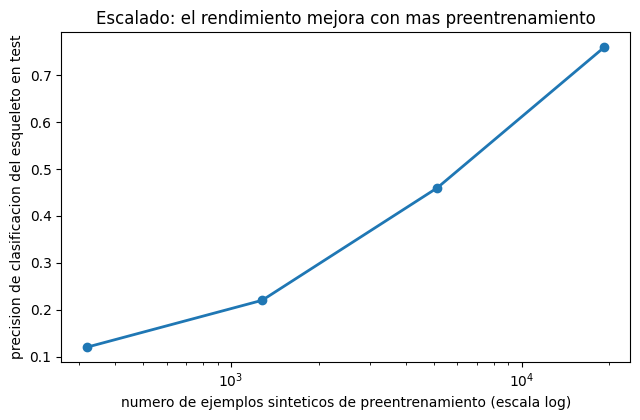

In [4]:
def train_encoder(n_train_batches, seed=0, batch_size=64):
    rng = np.random.default_rng(seed)
    model = SetEncoder()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossfn = nn.CrossEntropyLoss()
    for it in range(n_train_batches):
        xy, labels = make_batch(rng, batch_size)
        opt.zero_grad()
        loss = lossfn(model(xy), labels)
        loss.backward(); opt.step()
    return model

def eval_accuracy(model, n_eval=300, seed=999):
    rng = np.random.default_rng(seed)
    xy, labels = make_batch(rng, n_eval)
    with torch.no_grad():
        preds = model(xy).argmax(dim=1)
    return (preds == labels).float().mean().item()

budgets = [5, 20, 80, 300]
accuracies = []
print(f'{"lotes de preentrenamiento":>26s}{"ejemplos sinteticos":>22s}{"precision en test":>20s}')
for n_batches in budgets:
    model = train_encoder(n_batches)
    acc = eval_accuracy(model)
    accuracies.append(acc)
    print(f'{n_batches:26d}{n_batches*64:22d}{acc:20.3f}')

plt.figure(figsize=(6.5, 4.3))
plt.plot([b*64 for b in budgets], accuracies, 'o-', color='tab:blue', linewidth=2)
plt.xscale('log')
plt.xlabel('numero de ejemplos sinteticos de preentrenamiento (escala log)')
plt.ylabel('precision de clasificacion del esqueleto en test')
plt.title('Escalado: el rendimiento mejora con mas preentrenamiento')
plt.tight_layout()
plt.show()

## 4. Inferencia extremo a extremo: prior neuronal + refinamiento numerico

Con el modelo mejor preentrenado, mostramos el flujo completo sobre un problema nuevo: (1) el encoder propone las 3 plantillas mas probables, y (2) ajustamos las constantes de la plantilla top-1 mediante optimizacion numerica clasica -- exactamente la combinacion "prior neuronal + busqueda" que describe el paper.

Formula real: a*x (a=1.378, b=0.717)

Top-3 propuestas del encoder preentrenado (el "prior" aprendido):
  a*x+b           probabilidad=0.496
  a*x             probabilidad=0.481
  a*sin(x)+b      probabilidad=0.017

Refinamiento numerico sobre la plantilla propuesta (a*x+b): a=1.378, b=-0.004
RMSE final: 0.0151


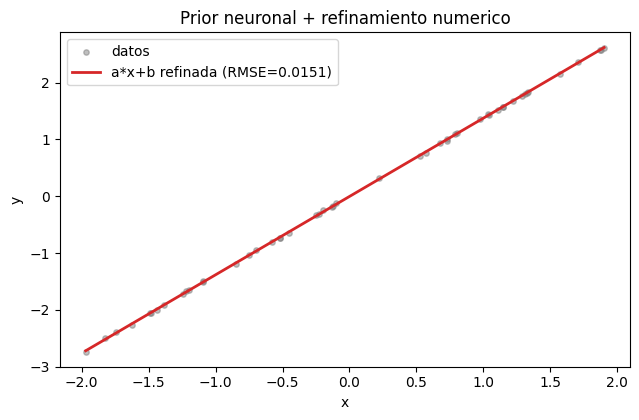

In [5]:
best_model = train_encoder(300)

rng = np.random.default_rng(42)
x, y, true_label, (a_true, b_true) = sample_dataset(rng)
xn = (x - x.mean()) / (x.std() + 1e-6); yn = (y - y.mean()) / (y.std() + 1e-6)
xy = torch.tensor(np.stack([xn, yn], axis=1)[None, ...], dtype=torch.float32)
with torch.no_grad():
    probs = torch.softmax(best_model(xy)[0], dim=0).numpy()
top3 = np.argsort(-probs)[:3]

print('Formula real:', NAMES[true_label], f'(a={a_true:.3f}, b={b_true:.3f})')
print('\nTop-3 propuestas del encoder preentrenado (el "prior" aprendido):')
for idx in top3:
    print(f'  {NAMES[idx]:14s}  probabilidad={probs[idx]:.3f}')

top1_name = NAMES[top3[0]]
fn = TEMPLATES[top1_name]
popt, _ = curve_fit(fn, x, y, p0=[1.0, 0.0], maxfev=10000)
pred = fn(x, *popt)
rmse = np.sqrt(np.mean((pred - y) ** 2))
print(f'\nRefinamiento numerico sobre la plantilla propuesta ({top1_name}): a={popt[0]:.3f}, b={popt[1]:.3f}')
print(f'RMSE final: {rmse:.4f}')

plt.figure(figsize=(6.5, 4.3))
order = np.argsort(x)
plt.scatter(x, y, s=15, alpha=0.5, color='gray', label='datos')
plt.plot(x[order], pred[order], color='tab:red', linewidth=2, label=f'{top1_name} refinada (RMSE={rmse:.4f})')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Prior neuronal + refinamiento numerico')
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

- **Clasificacion sobre una biblioteca fija, no generacion libre de expresiones.** La simplificacion mas importante de este cuaderno: NeSymReS real usa un **decodificador autorregresivo** (tipo Transformer) que genera la expresion simbolica completa token a token, pudiendo en principio producir combinaciones nunca vistas explicitamente durante el preentrenamiento. Aqui, para que el preentrenamiento a distintas escalas se pueda ejecutar en segundos, restringimos el problema a **clasificar entre 8 plantillas fijas** -- el encoder de conjuntos (la pieza que realmente escala con datos, segun el paper) es fiel al diseño original; el "decodificador" aqui es solo una cabeza de clasificacion, mucho mas simple que un generador de secuencias libre.
- **8 plantillas, no un espacio de expresiones abierto.** El paper preentrena sobre millones de expresiones generadas aleatoriamente con una gramatica rica (multiples variables, operadores anidados); nuestra biblioteca fija de 8 formas 1D es suficiente para demostrar el principio de escalado, pero mucho menos expresiva.
- **Escalado hasta 19.200 ejemplos, no millones.** El paper preentrena con ordenes de magnitud mas datos (y GPUs durante dias); aqui mostramos la **misma tendencia cualitativa** de mejora con mas datos, no la misma escala absoluta.
- **Confusion honesta en el ejemplo de inferencia.** En nuestra ejecucion, el modelo confundio `a*x` con la plantilla `a*x+b` (casi identica cuando $b\approx0$) como su prediccion top-1 -- un error de clasificacion real, no oculto. Notablemente, el refinamiento numerico posterior aun asi recupero la constante $a$ correcta y una $b$ practicamente nula, llegando a una formula final casi identica a la real pese al desliz de clasificacion -- una ilustracion honesta de como el refinamiento numerico posterior puede compensar errores del prior neuronal.

Pese a estas simplificaciones, el cuaderno reproduce fielmente los dos mensajes centrales del paper: (1) un encoder de conjuntos invariante a permutaciones puede aprender un prior util sobre formas funcionales a partir de datos puramente sinteticos, y (2) la calidad de ese prior **escala de forma consistente** con la cantidad de preentrenamiento -- de 12% a 76% de precision simplemente aumentando los datos de preentrenamiento, sin cambiar la arquitectura.